# World population prediction

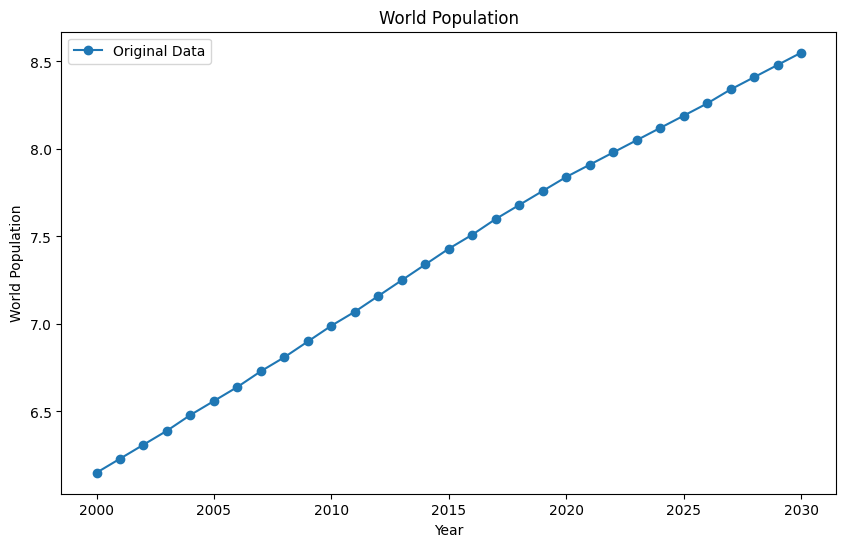

Mean Squared Error for each model:
Linear Regression: 0.0007084213441778888
Ridge Regression: 0.0007130516664241693
Lasso Regression: 0.015990606256675047

Best model: Linear Regression


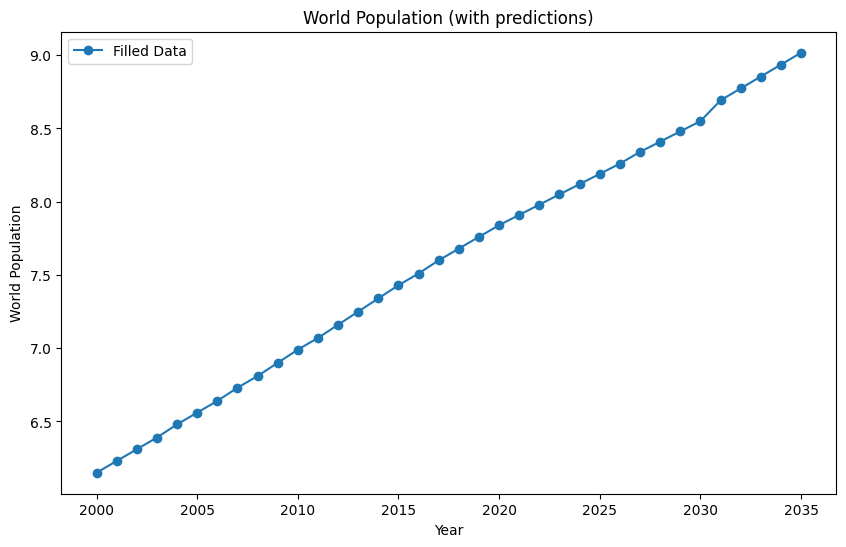


Filled DataFrame:
    Year  World Population
0   2000          6.150000
1   2001          6.230000
2   2002          6.310000
3   2003          6.390000
4   2004          6.480000
5   2005          6.560000
6   2006          6.640000
7   2007          6.730000
8   2008          6.810000
9   2009          6.900000
10  2010          6.990000
11  2011          7.070000
12  2012          7.160000
13  2013          7.250000
14  2014          7.340000
15  2015          7.430000
16  2016          7.510000
17  2017          7.600000
18  2018          7.680000
19  2019          7.760000
20  2020          7.840000
21  2021          7.910000
22  2022          7.980000
23  2023          8.050000
24  2024          8.120000
25  2025          8.190000
26  2026          8.260000
27  2027          8.340000
28  2028          8.410000
29  2029          8.480000
30  2030          8.550000
31  2031          8.691935
32  2032          8.773246
33  2033          8.854556
34  2034          8.935867
35  2035 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare the data
data = {
    "Year": np.arange(2000, 2036),
    "World Population": [6.15, 6.23, 6.31, 6.39, 6.48, 6.56, 6.64, 6.73, 6.81, 6.9, 6.99, 7.07, 7.16, 
                         7.25, 7.34, 7.43, 7.51, 7.6, 7.68, 7.76, 7.84, 7.91, 7.98, 8.05, 8.12, 8.19, 8.26, 8.34, 8.41, 8.48, 8.55,
                        np.nan, np.nan, np.nan, np.nan, np.nan]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plot the original data
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['World Population'], label='Original Data', marker='o')
plt.xlabel('Year')
plt.ylabel('World Population')
plt.title('World Population')
plt.legend()
plt.show()

# Split the data into known and missing
known_data = df.dropna()
missing_data = df[df.isna().any(axis=1)]

# Prepare the feature matrix X and target vector y for training
X = known_data[['Year']]
y = known_data['World Population']

# Train regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    #"SVR": SVR()
}

results = {}
for name, model in models.items():
    # Split the known data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=21)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Validate the model
    y_pred_val = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred_val)
    results[name] = mse

# Print MSE for each model
print("Mean Squared Error for each model:")
for name, mse in results.items():
    print(f"{name}: {mse}")

# Select the best model (with the lowest MSE)
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest model: {best_model_name}")

# Train the best model on the entire known dataset
best_model.fit(X, y)

# Predict the missing values
X_missing = missing_data[['Year']]
y_missing_pred = best_model.predict(X_missing)

# Fill the missing values in the original dataframe
df.loc[df.isna().any(axis=1), 'World Population'] = y_missing_pred

# Plot the filled data
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['World Population'], label='Filled Data', marker='o')
plt.xlabel('Year')
plt.ylabel('World Population')
plt.title('World Population (with predictions)')
plt.legend()
plt.show()

# Print the filled dataframe
print("\nFilled DataFrame:")
print(df)


# Global electricity usage prediction

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   31
Model:                    AutoReg(10)   Log Likelihood                -162.535
Method:               Conditional MLE   S.D. of innovations            556.019
Date:                Sat, 12 Apr 2025   AIC                            349.069
Time:                        19:40:01   BIC                            361.603
Sample:                            10   HQIC                           351.789
                                   31                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -717.0577    913.659     -0.785      0.433   -2507.796    1073.680
y.L1           0.7216      0.198      3.643      0.000       0.333       1.110
y.L2           0.4393      0.248      1.774      0.0

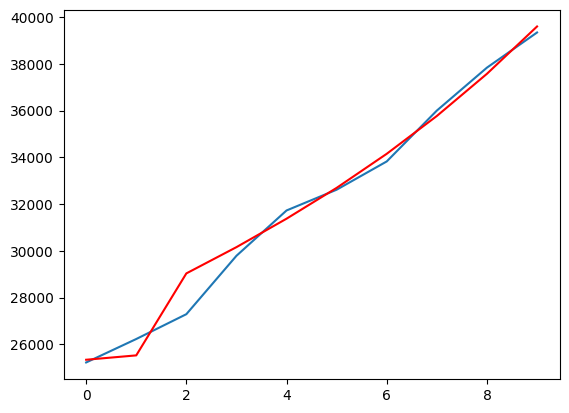

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare the data
data = {
    "Year": np.arange(2000, 2031),
    "Global Electricity": [13261, 13393, 13839, 14384, 15027, 15681, 16327, 17133, 17443, 17353, 18753, 19444, 19924, 20578,
                        20987, 21405, 22028, 22722, 23536, 23921, 23966, 25343, 25530, 29035, 30158, 31375, 32693, 
                        34150, 35767, 37571, 39594]                                 
}

# Create DataFrame
df = pd.DataFrame(data)
df.set_index("Year", inplace=True)
X=df.values

from statsmodels.tsa.ar_model import AutoReg

train = X[:len(X)-10]
test = X[len(X)-10:]

model = AutoReg(X,lags=10).fit()

print(model.summary())

pred = model.predict(start=len(train),end=len(X)-1,dynamic=False)

from matplotlib import pyplot
pyplot.plot(pred)
pyplot.plot(test, color= 'red')
print(pred)


In [3]:
pred_future = model.predict(start=len(X), end=len(X)+4, dynamic=False)
print("The future prediction for the next 5 years")
print(pred_future)
print('Number of predictions made: \t', len(pred_future))

The future prediction for the next 5 years
[40521.75048706 40597.27042379 42734.64464334 44179.48227328
 46343.03079752]
Number of predictions made: 	 5


# Global GHG emission prediction

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   31
Model:                     AutoReg(8)   Log Likelihood                 -39.243
Method:               Conditional MLE   S.D. of innovations              1.333
Date:                Sat, 12 Apr 2025   AIC                             98.486
Time:                        19:40:01   BIC                            109.841
Sample:                             8   HQIC                           101.342
                                   31                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4146      3.341     -1.022      0.307      -9.963       3.134
y.L1           1.0461      0.208      5.029      0.000       0.638       1.454
y.L2           0.1813      0.296      0.613      0.5

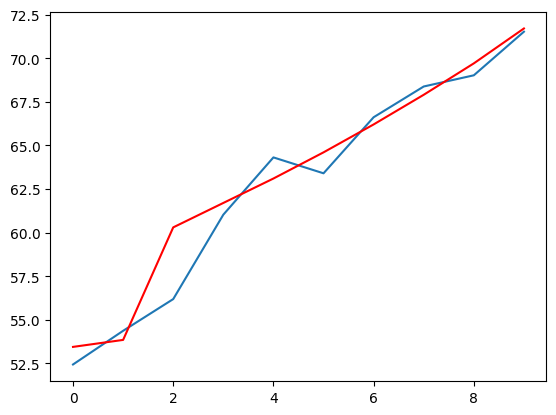

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare the data
data = {
    "Year": np.arange(2000, 2031),
    "Global GHG emission": [40.77, 40.61, 41.55, 43.61, 44.33, 44.95, 46.47, 46.78, 47.58, 47.49, 49.42, 50.94, 51.71, 51.46, 52.16,
                            52.56, 51.55, 52.25, 52.82, 53.46, 51.46, 53.45, 53.85, 60.3, 61.7, 63.1, 64.6, 66.2, 67.9, 69.7, 71.7]                                 
}

# Create DataFrame
df = pd.DataFrame(data)
df.set_index("Year", inplace=True)
X=df.values

from statsmodels.tsa.ar_model import AutoReg

train = X[:len(X)-10]
test = X[len(X)-10:]

model = AutoReg(X,lags=8).fit()

print(model.summary())

pred = model.predict(start=len(train),end=len(X)-1,dynamic=False)

from matplotlib import pyplot
pyplot.plot(pred)
pyplot.plot(test, color= 'red')
print(pred)


In [5]:
pred_future = model.predict(start=len(X), end=len(X)+4, dynamic=False)
print("The future prediction for the next 5 years")
print(pred_future)
print('Number of predictions made: \t', len(pred_future))

The future prediction for the next 5 years
[73.95816525 76.38624045 78.96789585 81.68860916 84.59874882]
Number of predictions made: 	 5
